# Task 4: Classification with Logistic Regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, accuracy_score,
)

In [2]:
# -----------------------------------------------------------------
# 1. LOAD THE DATASET
# -----------------------------------------------------------------
df = pd.read_csv("breast_cancer.csv")

print("=" * 60)
print("STEP 1: Dataset overview")
print("=" * 60)
print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass balance (diagnosis: 1=malignant, 0=benign):")
print(df["diagnosis"].value_counts())

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

STEP 1: Dataset overview
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

In [3]:
# -----------------------------------------------------------------
# 2. TRAIN/TEST SPLIT + STANDARDIZE FEATURES
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 2: Train/test split & standardization")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Logistic Regression uses distance-based optimization (gradient descent on
# a convex loss), so features on very different scales (e.g. 'mean area' in
# the hundreds vs 'mean smoothness' around 0.1) will distort the fit. We fit
# the scaler ONLY on training data, then apply it to both sets, to avoid
# leaking test-set information into preprocessing.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized: mean ~0, std ~1 (fit on train only).")


STEP 2: Train/test split & standardization
Train size: 455, Test size: 114
Features standardized: mean ~0, std ~1 (fit on train only).


In [4]:
# -----------------------------------------------------------------
# 3. FIT LOGISTIC REGRESSION MODEL
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 3: Fitting Logistic Regression")
print("=" * 60)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model fit complete.")

# Default predictions at threshold 0.5
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (malignant)
y_pred_default = model.predict(X_test_scaled)      # sklearn's default 0.5 threshold


STEP 3: Fitting Logistic Regression
Model fit complete.


In [5]:
# -----------------------------------------------------------------
# 4. EVALUATE: CONFUSION MATRIX, PRECISION, RECALL, ROC-AUC
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 4: Evaluation @ default threshold = 0.5")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm.ravel()
acc = accuracy_score(y_test, y_pred_default)
prec = precision_score(y_test, y_pred_default)
rec = recall_score(y_test, y_pred_default)
f1 = f1_score(y_test, y_pred_default)
auc = roc_auc_score(y_test, y_prob)

print("Confusion matrix:")
print(f"                Predicted Benign  Predicted Malignant")
print(f"Actual Benign        {tn:4d}              {fp:4d}")
print(f"Actual Malignant     {fn:4d}              {tp:4d}")
print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}  (of predicted malignant, how many truly are)")
print(f"Recall   : {rec:.4f}  (of actual malignant, how many we caught)")
print(f"F1 score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


STEP 4: Evaluation @ default threshold = 0.5
Confusion matrix:
                Predicted Benign  Predicted Malignant
Actual Benign          71                 1
Actual Malignant        3                39

Accuracy : 0.9649
Precision: 0.9750  (of predicted malignant, how many truly are)
Recall   : 0.9286  (of actual malignant, how many we caught)
F1 score : 0.9512
ROC-AUC  : 0.9960


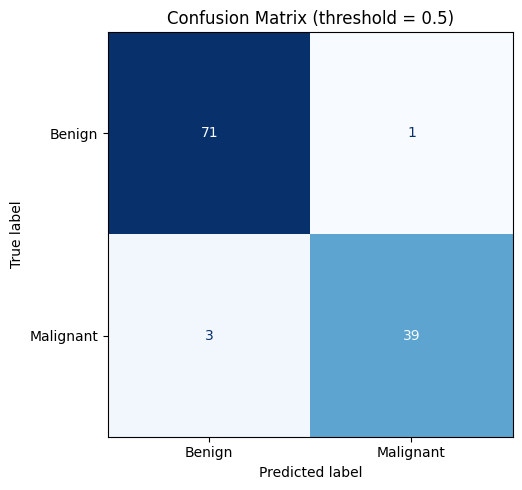

In [7]:
# Plot 1: Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()
plt.close()

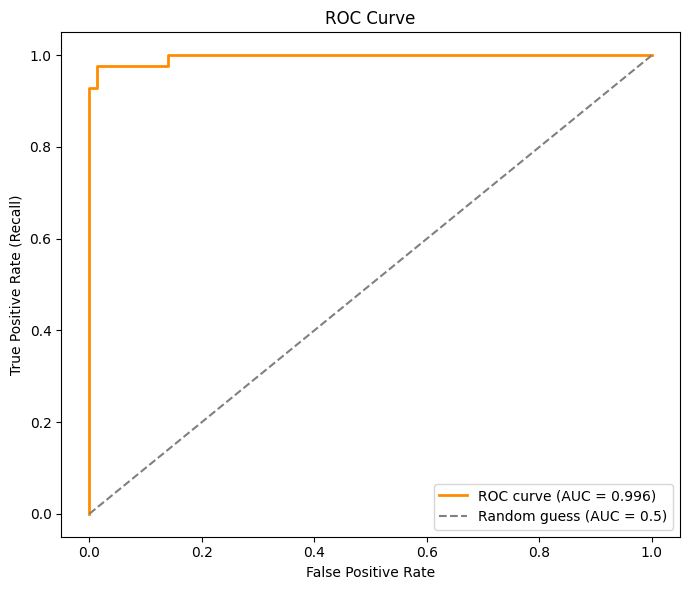

In [8]:
# Plot 2: ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


In [9]:
# -----------------------------------------------------------------
# 5. TUNE THRESHOLD & EXPLAIN SIGMOID
# -----------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 5: Threshold tuning")
print("=" * 60)

print("""
Logistic Regression outputs a *probability* via the sigmoid function:

    sigmoid(z) = 1 / (1 + e^(-z))       where z = w1*x1 + w2*x2 + ... + b

- z (the 'logit') is an unbounded linear combination of the features -
  it can be any real number, from -infinity to +infinity.
- sigmoid() squashes z into the range (0, 1), so it can be read as a
  probability of the positive class (here: malignant).
- The S-shape means: large negative z -> probability near 0,
  large positive z -> probability near 1, and z = 0 -> probability = 0.5.
- By DEFAULT, sklearn (and most classifiers) turn that probability into a
  class label by checking if probability >= 0.5. But 0.5 is just a
  convention - nothing forces us to use it.
""")


STEP 5: Threshold tuning

Logistic Regression outputs a *probability* via the sigmoid function:
 
    sigmoid(z) = 1 / (1 + e^(-z))       where z = w1*x1 + w2*x2 + ... + b
 
- z (the 'logit') is an unbounded linear combination of the features -
  it can be any real number, from -infinity to +infinity.
- sigmoid() squashes z into the range (0, 1), so it can be read as a
  probability of the positive class (here: malignant).
- The S-shape means: large negative z -> probability near 0,
  large positive z -> probability near 1, and z = 0 -> probability = 0.5.
- By DEFAULT, sklearn (and most classifiers) turn that probability into a
  class label by checking if probability >= 0.5. But 0.5 is just a
  convention - nothing forces us to use it.



In [10]:
# Try a range of thresholds and see how precision/recall trade off
thresholds_to_try = np.arange(0.1, 1.0, 0.05)
results = []
for t in thresholds_to_try:
    y_pred_t = (y_prob >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    results.append({"threshold": round(t, 2), "precision": p, "recall": r, "f1": f})

threshold_df = pd.DataFrame(results)
print(threshold_df.to_string(index=False))

 threshold  precision   recall       f1
      0.10   0.891304 0.976190 0.931818
      0.15   0.911111 0.976190 0.942529
      0.20   0.911111 0.976190 0.942529
      0.25   0.976190 0.976190 0.976190
      0.30   0.976190 0.976190 0.976190
      0.35   0.975610 0.952381 0.963855
      0.40   0.975610 0.952381 0.963855
      0.45   0.975610 0.952381 0.963855
      0.50   0.975000 0.928571 0.951220
      0.55   1.000000 0.928571 0.962963
      0.60   1.000000 0.904762 0.950000
      0.65   1.000000 0.904762 0.950000
      0.70   1.000000 0.904762 0.950000
      0.75   1.000000 0.904762 0.950000
      0.80   1.000000 0.857143 0.923077
      0.85   1.000000 0.857143 0.923077
      0.90   1.000000 0.785714 0.880000
      0.95   1.000000 0.738095 0.849315


In [11]:
# Pick a "high recall" threshold - in medical screening, missing a malignant
# case (false negative) is usually far worse than a false alarm (false
# positive), so we might deliberately LOWER the threshold below 0.5 to
# catch more true positives at the cost of some extra false positives.
best_recall_row = threshold_df[threshold_df["recall"] >= 0.98].iloc[-1] if (threshold_df["recall"] >= 0.98).any() else threshold_df.iloc[0]
tuned_threshold = best_recall_row["threshold"]

y_pred_tuned = (y_prob >= tuned_threshold).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()

print(f"\nExample tuned threshold (favoring recall for a medical use-case): {tuned_threshold}")
print(f"Confusion matrix @ threshold={tuned_threshold}:")
print(f"                Predicted Benign  Predicted Malignant")
print(f"Actual Benign        {tn_t:4d}              {fp_t:4d}")
print(f"Actual Malignant     {fn_t:4d}              {tp_t:4d}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tuned):.4f}")



Example tuned threshold (favoring recall for a medical use-case): 0.1
Confusion matrix @ threshold=0.1:
                Predicted Benign  Predicted Malignant
Actual Benign          67                 5
Actual Malignant        1                41
Precision: 0.8913
Recall   : 0.9762


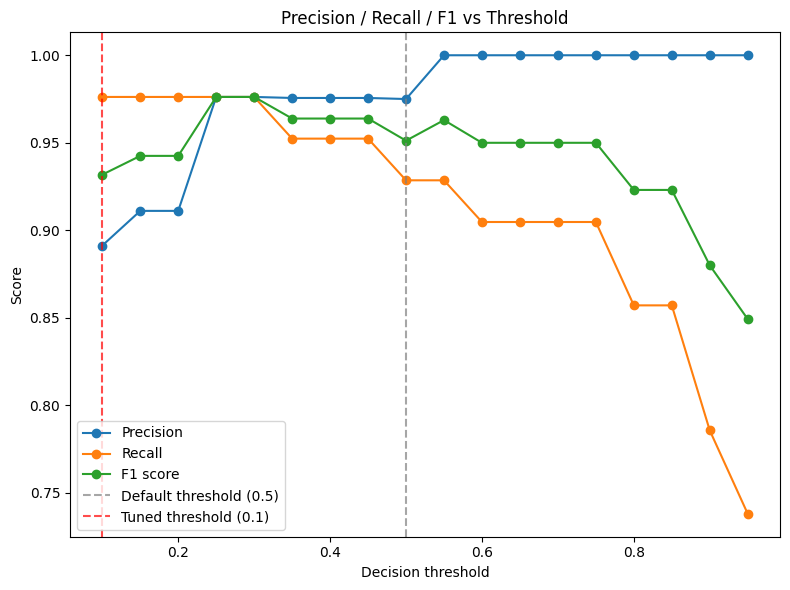

In [13]:
# Plot 3: Precision/Recall vs threshold
plt.figure(figsize=(8, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1 score")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="Default threshold (0.5)")
plt.axvline(tuned_threshold, color="red", linestyle="--", alpha=0.7, label=f"Tuned threshold ({tuned_threshold})")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()


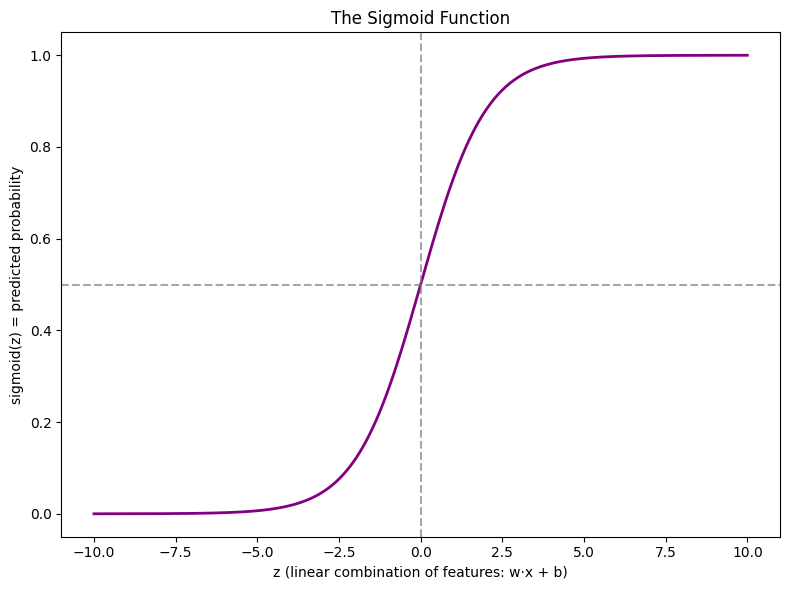

In [14]:
# Plot 4: The sigmoid function itself
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))
plt.figure(figsize=(8, 6))
plt.plot(z, sigmoid, color="purple", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7)
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.xlabel("z (linear combination of features: w·x + b)")
plt.ylabel("sigmoid(z) = predicted probability")
plt.title("The Sigmoid Function")
plt.tight_layout()
plt.show()
plt.close()


In [16]:
# Save summary CSVs
metrics_summary = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "value_at_threshold_0.5": [acc, prec, rec, f1, auc],
})
metrics_summary.to_csv("metrics_summary.csv", index=False)
threshold_df.to_csv("threshold_tuning_results.csv", index=False)

print("\nSaved metrics_summary.csv and threshold_tuning_results.csv")


Saved metrics_summary.csv and threshold_tuning_results.csv
